# 多変量データ解析入門
## 基礎 (2) 1次元データの処理

- 使用するパッケージ: pandas, matplotlib, chardet, re

## このノートで学ぶこと
1. CSVの読み込みと数値列の選択
2. 基礎統計量の計算と時系列プロットの可視化とヒストグラムの表示

## セットアップ

- 以下はデータの読み込み時のエラーをできる限り無くしたり、図を綺麗にしたりするためのセットアップ。初学者の段階では中身の理解をスキップしてかまわない。


In [61]:
import pandas as pd
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import re

# ■ 論文っぽい見た目の共通スタイル（覚えなくてOK）
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 600,
    "savefig.transparent": True,
})

def safe_read_csv(path: Path) -> pd.DataFrame:
    """文字コードを自動判定してCSVを安全に読み込む """
    import chardet
    with open(path, "rb") as f:
        enc = chardet.detect(f.read(10000)).get("encoding") or "utf-8-sig"
    try:
        return pd.read_csv(path, encoding=enc)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="utf-8-sig")

def select_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """存在する列だけ、指定順のまま抜き出す """
    return df.reindex(columns=columns)

def plot_timeseries_with_right_hist(x, y, x_label: str, y_label: str,
                                    date_fmt="%Y-%m-%d",
                                    figsize=(5, 2.5),
                                    save_eps_path: str | None = None):
    """右側にヒストグラムを並べた時系列図 """
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

    # 左：時系列
    ax_ts = fig.add_subplot(gs[0])
    ax_ts.plot(x, y, color="black", marker="o", ms=2)
    ax_ts.set_xlabel(x_label); ax_ts.set_ylabel(y_label)
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    fig.autofmt_xdate(rotation=90, ha="center")
    ax_ts.grid(True, linewidth=0.5, alpha=0.5)

    # 右：ヒスト（共有Y軸）
    ax_hist = fig.add_subplot(gs[1], sharey=ax_ts)
    ax_hist.hist(pd.to_numeric(y, errors="coerce").dropna(), bins=20,
                 orientation="horizontal", color="0.6",
                 edgecolor="black", linewidth=0.5)
    ax_hist.set_xlabel("Count")
    plt.setp(ax_hist.get_yticklabels(), visible=False)
    ax_hist.grid(True, linewidth=0.5, alpha=0.3)

    plt.subplots_adjust(left=0.18, right=0.95, bottom=0.28, top=0.95)

    if save_eps_path:
        plt.savefig(save_eps_path, format="eps", bbox_inches="tight", pad_inches=0.02)
    plt.show()


## データ場所の指定とインポート
- `DATA_PATH` にファイルの場所（パス）を代入すると、そのデータをデータフレームとしてdfに代入する。
- 今回読み込むデータはMorimoto_et_al_SI_A1.csv。現在投稿中の森本響子さんの主著の論文のsupplementary informationのデータの一部抜粋。
- ここではDate, Temprature, pH, EC, DO, Ehのみを使用することとし、それらの列だけを残してdfを再定義する。

In [59]:
# 1) dfにデータを読み込み（読めないときはsafe_read_csvに差し替え）
DATA_PATH = Path("Morimoto_et_al_SI_A1.csv")
# df = pd.read_csv(DATA_PATH)
df = safe_read_csv(DATA_PATH)   # ← 文字コードを自動で判定・安全

# 2) 一部の列をリストで指定し、dfに再定義
print(df.columns.tolist())    # まず列名一覧を確認
cols_selected = ["Date", "Temperature", "pH", "EC (É\xa0S/cm)", "DO (mg/L)", "Eh (mV vs. SHE)"]
df = select_columns(df, cols_selected)

['Date', 'Depth', 'Temperature', 'pH', 'Eh (mV vs. Ag/AgCl)', 'EC (É\xa0S/cm)', 'DO (mg/L)', 'Eh (mV vs. SHE)', 'log10 O2 (M)', 'log O2 (M)']


## 2. 基本統計量の計算、時系列プロットの作成、ヒストグラムの作成

--- Temperature の統計 ---
平均値: 13.564
最小値: 2.400
最大値: 30.700


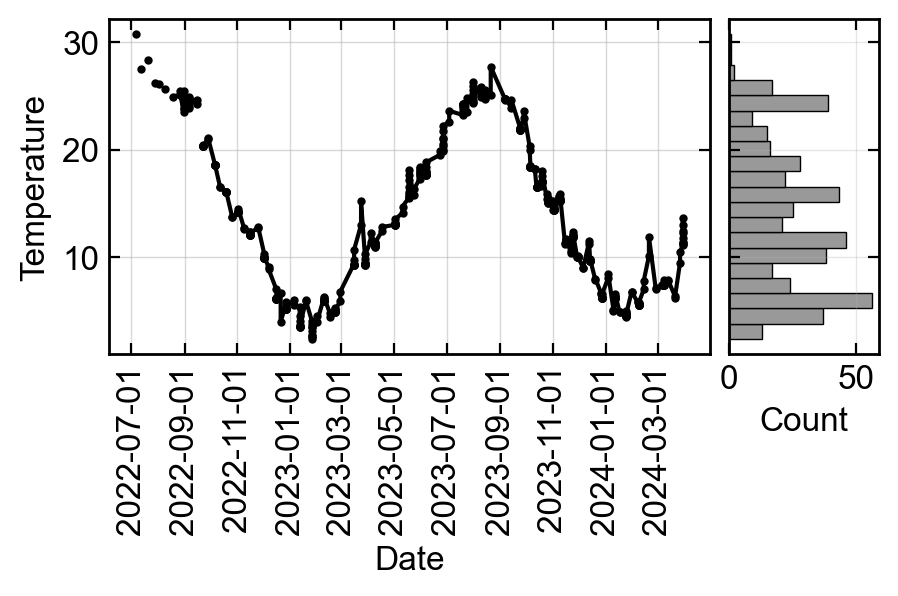

In [62]:
# 3) x,y を作る（xには必ず'Date'列を用い、yにはその他の列を用いる）
x = pd.to_datetime(df.iloc[:, 0], errors="coerce", format="%Y.%m.%d")
y = pd.to_numeric(df.iloc[:, 1], errors="coerce")
y_name = df.columns[1]

# 4) 統計を表示
print(f"--- {y_name} の統計 ---")
print(f"平均値: {y.mean():.3f}")
print(f"最小値: {y.min():.3f}")
print(f"最大値: {y.max():.3f}")

# 5) 右にヒストグラムを添えた時系列図（EPS保存したいときはsave_eps_pathを指定）
plot_timeseries_with_right_hist(
    x=x, y=y,
    x_label=df.columns[0],
    y_label=y_name,
    date_fmt="%Y-%m-%d",
    figsize=(5, 2.5),
    # save_eps_path="figure_with_hist.eps",  # ← 保存したいときにコメント解除
)


## 演習
pH, EC, DO, Ehについても同様に、
1. 平均値、最小値、最大値を計算し、
2. 時系列プロットとヒストグラムを表示せよ。